# BART demo: `tree_ensembles.bart` on two TabReD datasets

What this notebook shows, for a regression task (**cooking-time**) and a binary
classification task (**homesite-insurance**):

1. fit / predict / predict_proba, compared with my default XGBoost;
2. uncertainty: posterior sd, predictive sd, and 95% HPDI intervals for f(x) and for a new y;
3. parameters: posterior mean, sd and 95% HPDI (e.g. the noise sd sigma);
4. MCMC convergence diagnostics (R-hat, ESS, trace and rank plots);
5. what the trees look like: depth, leaves, which features and cut values they use.

Runtime on a laptop CPU is a few minutes with the sizes below. BART's cost grows with
rows x trees x iterations for fitting, and with test rows x draws x trees for predicting.

In [1]:
# Must run before anything uses JAX: lets the 4 MCMC chains run in parallel on CPU.
import jax

jax.config.update("jax_num_cpu_devices", 4)

In [2]:
import os
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import roc_auc_score

from tree_ensembles.bart import BartClassifier, BartRegressor
from tree_ensembles.bart.plots import plot_rank, plot_trace, plot_tree_sizes, plot_variable_usage
from tree_ensembles.xgb import XGBDefaultClassifier, XGBDefaultRegressor

DATA_DIR = Path(os.environ.get("TREE_ENSEMBLES_DATA", "../data"))
N_TRAIN = 20_000  # training rows sampled from the default split (None = all, ~225k)
N_TEST = 5_000  # test rows sampled (None = all)
BART_SETTINGS = dict(num_trees=200, n_burn=500, n_save=500, num_chains=4, show_progress=False)

In [3]:
DATA_DIR

PosixPath('../data')

## Data

Each TabReD folder has numeric (`x_num`), binary (`x_bin`) and categorical (`x_cat`, integer
codes) features, `y`, and train/val/test splits. Categorical codes are used as numbers here
(trees can still split them, but in code order).

**Missing values.** bartz accepts NaN but bins it poorly: every NaN counts as a distinct value
when cutpoints are chosen, which crowds out real cutpoints and creates splits that do nothing
(reported to bartz). Until that is fixed, `BartRegressor` / `BartClassifier` handle NaN
themselves: they median-impute (medians from the training rows) and add a 0/1 `<name>_missing`
column for every feature missing in more than 50% of the training rows, so the trees can split
on missingness (`impute_strategy`, `missing_indicator_threshold`). XGBoost handles NaN natively,
so both models get the same raw data.

In [4]:
def load_tabred(name, n_train=N_TRAIN, n_test=N_TEST, seed=0):
    """Train/test features and targets from a TabReD folder (default split)."""
    folder = DATA_DIR / name
    blocks = []
    for kind in ["num", "bin", "cat"]:
        path = folder / f"x_{kind}.npy"
        if path.exists():
            values = np.load(path).astype(np.float32)
            names = [f"{kind}_{j}" for j in range(values.shape[1])]
            blocks.append(pd.DataFrame(values, columns=names))
    X = pd.concat(blocks, axis=1)
    y = np.load(folder / "y.npy")

    rng = np.random.default_rng(seed)

    def rows(split, n):
        idx = np.load(folder / "splits" / "default" / f"{split}.npy")
        return np.sort(rng.choice(idx, n, replace=False)) if n and n < len(idx) else idx

    train, test = rows("train", n_train), rows("test", n_test)
    return (
        X.iloc[train].reset_index(drop=True),
        y[train],
        X.iloc[test].reset_index(drop=True),
        y[test],
    )

## Part 1. Regression: cooking-time

### Fit and compare with XGBoost

In [5]:
X_train, y_train, X_test, y_test = load_tabred("cooking-time")
print("columns with NaN:", int(X_train.isna().any().sum()), "of", X_train.shape[1])
print("columns missing in > 50% of rows:", int((X_train.isna().mean() > 0.5).sum()))
print("train", X_train.shape, "test", X_test.shape)

columns with NaN: 56 of 192
columns missing in > 50% of rows: 5
train (20000, 192) test (5000, 192)


In [6]:
start = time.time()
reg = BartRegressor(**BART_SETTINGS).fit(X_train, y_train)  # imputes NaN itself
bart_pred = reg.predict(X_test)  # posterior mean of f(x); also waits for the MCMC to finish
print(f"BART fit + predict: {time.time() - start:.0f}s")
print("missing indicators added by BART:", len(reg.model_feature_names_) - X_train.shape[1])

xgb_reg = XGBDefaultRegressor().fit(X_train, y_train)
xgb_pred = xgb_reg.predict(X_test)


def rmse(pred):
    return np.sqrt(np.mean((pred - y_test) ** 2))


print(f"test RMSE  BART {rmse(bart_pred):.4f}   XGBoost {rmse(xgb_pred):.4f}")

BART fit + predict: 19s
missing indicators added by BART: 5


test RMSE  BART 0.4831   XGBoost 0.4860


### Uncertainty for each test row

- `predict_dist`: posterior **mean** of f(x), its posterior **sd** (how unsure the model is about
  the mean), and the **predictive sd** of a new y at x, which also includes the noise:
  `predictive_sd² = sd² + E[sigma²]`.
- `predict_interval(kind="mean")`: credible interval for **f(x)**, the average y at x.
- `predict_interval(kind="predictive")`: interval for **a new observation y**. It is much wider,
  and it is the one that should cover about 95% of the actual test values.

In [7]:
dist = reg.predict_dist(X_test)
dist.head()

,mean,sd,predictive_sd
0,2.021366,0.077902,0.463580
1,2.643525,0.093446,0.466443
2,2.708869,0.083878,0.464621
3,3.154713,0.071972,0.462620
4,2.562887,0.094767,0.466710


In [8]:
mean_ci = reg.predict_interval(X_test, prob=0.95, kind="mean")
pred_ci = reg.predict_interval(X_test, prob=0.95, kind="predictive")


def coverage(ci):
    return np.mean((y_test >= ci["lower"]) & (y_test <= ci["upper"]))


pd.DataFrame(
    {
        "share of test y inside": [coverage(mean_ci), coverage(pred_ci)],
        "average width": [
            (mean_ci.upper - mean_ci.lower).mean(),
            (pred_ci.upper - pred_ci.lower).mean(),
        ],
    },
    index=["95% HPDI of f(x)", "95% predictive HPDI of y"],
)

,share of test y inside,average width
95% HPDI of f(x),0.3114,0.360548
95% predictive HPDI of y,0.9346,1.810772


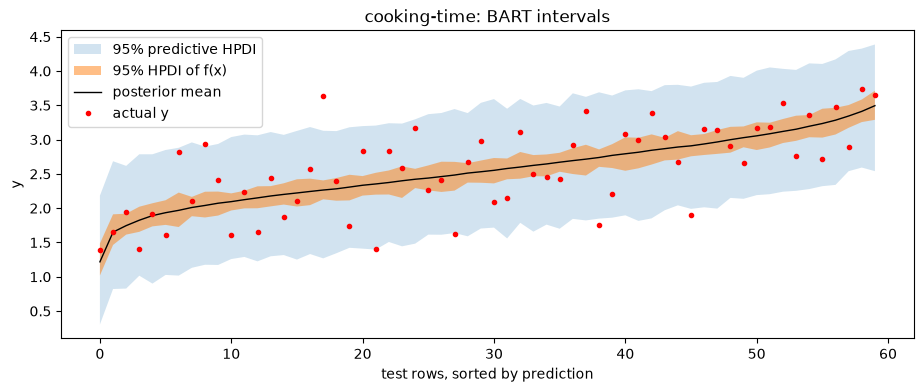

In [9]:
show = np.argsort(bart_pred)[:: len(bart_pred) // 60][:60]  # 60 rows spread over the range
x = np.arange(len(show))
fig, ax = plt.subplots(figsize=(11, 4))
ax.fill_between(x, pred_ci.lower[show], pred_ci.upper[show], alpha=0.2, label="95% predictive HPDI")
ax.fill_between(x, mean_ci.lower[show], mean_ci.upper[show], alpha=0.5, label="95% HPDI of f(x)")
ax.plot(x, bart_pred[show], "k-", lw=1, label="posterior mean")
ax.plot(x, y_test[show], "r.", label="actual y")
ax.set(xlabel="test rows, sorted by prediction", ylabel="y", title="cooking-time: BART intervals")
ax.legend(loc="upper left");

`predict_samples(X)` returns the raw posterior draws (one row per draw, one column per test row),
in case you want a quantity the methods above do not compute, e.g. P(f(x) > 3):

In [10]:
draws = reg.predict_samples(X_test[:5])  # shape (n_draws, 5): 4 chains x 500 draws
print(draws.shape)
print("P(f(x) > 3) for the first 5 test rows:", (draws > 3).mean(axis=0).round(3))

(2000, 5)
P(f(x) > 3) for the first 5 test rows: [0.   0.   0.   0.99 0.  ]


### Parameters: posterior summary (95% HPDI)

`sigma` is the noise sd. `mean_tree_leaves` / `mean_tree_depth` summarize the size of the trees in
each draw. R-hat and ESS tell whether these numbers can be trusted (next section).

In [11]:
reg.posterior_summary()

,mean,sd,hpdi_0.95_low,hpdi_0.95_high,rhat,ess_bulk,ess_tail,ok
name,,,,,,,,
sigma,0.456981,0.002382,0.452391,0.461429,1.032368,109.022603,1774.074441,False
mean_tree_leaves,2.404993,0.053294,2.305000,2.510000,1.027360,130.779352,397.805644,False
mean_tree_depth,1.355890,0.046656,1.265000,1.440000,1.027104,146.124122,417.248000,False


### Convergence diagnostics

`diagnostics()` adds the MH acceptance rate and **f(x) at 20 training rows**: the model's
prediction at 20 fixed rows, tracked across draws. When fitting, the model keeps a *copy* of 20
random training rows for this; they are not held out, and the model is fit on all training rows.
They check that the *predictions* have converged, not only the global parameters. You can pass
any rows instead, e.g. test rows, with `diagnostics(X_probe=X_test[:50])`.

Rule of thumb (Vehtari et al. 2021): R-hat < 1.01 and bulk/tail ESS > 400. In BART, sigma and
the tree size often mix slowly; the fix is a longer `n_burn` / `n_save` or more chains.

In [13]:
diag = reg.diagnostics()
diag[["mean", "rhat", "ess_bulk", "ess_tail", "ok"]]

/var/folders/z6/6gqdsxwx6blf3zqz985_x_b40000gn/T/ipykernel_29643/1730335640.py:1: UserWarning: Possible lack of convergence for: ['sigma', 'mean_tree_leaves', 'mean_tree_depth', 'f(x_probe[0])', 'f(x_probe[1])', 'f(x_probe[2])', 'f(x_probe[3])', 'f(x_probe[4])', 'f(x_probe[5])', 'f(x_probe[6])', 'f(x_probe[7])', 'f(x_probe[8])', 'f(x_probe[9])', 'f(x_probe[10])', 'f(x_probe[11])', 'f(x_probe[12])', 'f(x_probe[13])', 'f(x_probe[14])', 'f(x_probe[15])', 'f(x_probe[16])', 'f(x_probe[17])', 'f(x_probe[18])', 'f(x_probe[19])']
  diag = reg.diagnostics()


,mean,rhat,ess_bulk,ess_tail,ok
name,,,,,
sigma,0.456981,1.032368,109.022603,1774.074441,False
mean_tree_leaves,2.404993,1.027360,130.779352,397.805644,False
mean_tree_depth,1.355890,1.027104,146.124122,417.248000,False
accept_rate,0.315887,1.000462,902.967284,1853.869031,True
f(x_probe[0]),2.935016,1.669424,6.335742,19.013748,False
f(x_probe[1]),2.536689,1.203755,15.269314,34.909425,False
f(x_probe[2]),2.411733,1.131016,21.172456,80.658848,False
f(x_probe[3]),2.341167,1.466687,7.845793,35.655926,False
f(x_probe[4]),2.201089,1.158473,20.922267,107.508922,False


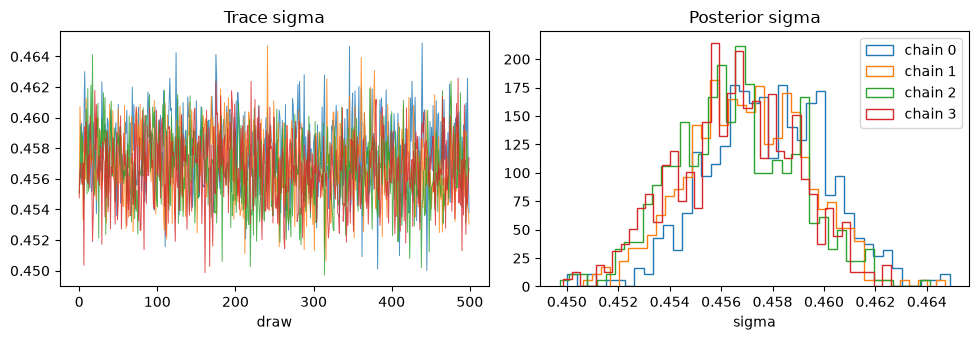

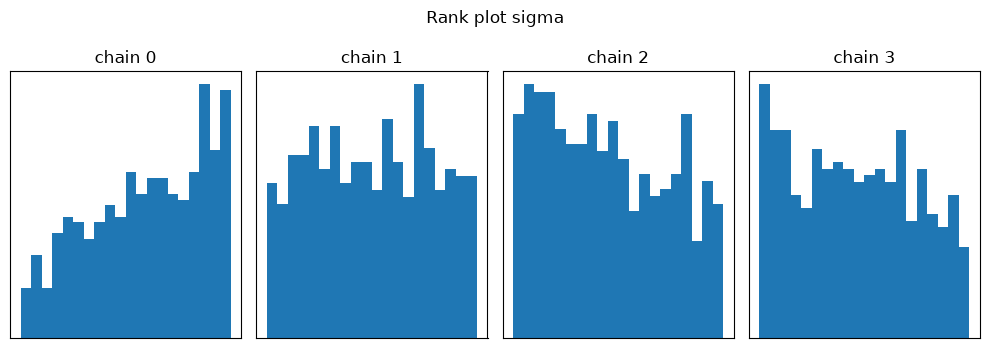

In [13]:
params = reg.parameter_draws()  # each (chain, draw)
plot_trace(params["sigma"], "sigma")
plot_rank(params["sigma"], "sigma");

**Reading these results.** With these short demo chains, sigma is close to converged, but the
tree size and f(x) at single rows are flagged: the 4 chains disagree (R-hat well above 1.01) and
the ESS is tiny. This is real, not a bug (the numbers match ArviZ), and longer chains help only
slowly: on this data, 2,000 burn-in + 1,000 draws per chain still gave R-hat about 1.5 for some
f(x). BART is known to mix slowly for large n, because the trees rarely restructure once grown.

What this means in practice:

- The **predictions** (posterior mean) are still good, as the RMSE above shows; pooling 4 chains
  also averages over the different places the chains got stuck.
- The **intervals** may be too narrow or too wide, because each chain explores only part of the
  posterior. Check the predictive coverage on held-out data (as above, against the 95% target).
- To improve mixing: more chains (`num_chains`), much longer runs (`n_burn`, `n_save`, thinning
  with `bartz_params={"n_skip": ...}`), or fewer, larger trees.

### What the trees look like

Every draw has 200 trees. Most BART trees are small (1-3 splits): the fit is a sum of many weak
trees. Variable usage counts how often each feature is used to split, averaged over draws.

share of trees by depth:
0    0.083
1    0.560
2    0.285
3    0.064
4    0.008
5    0.000


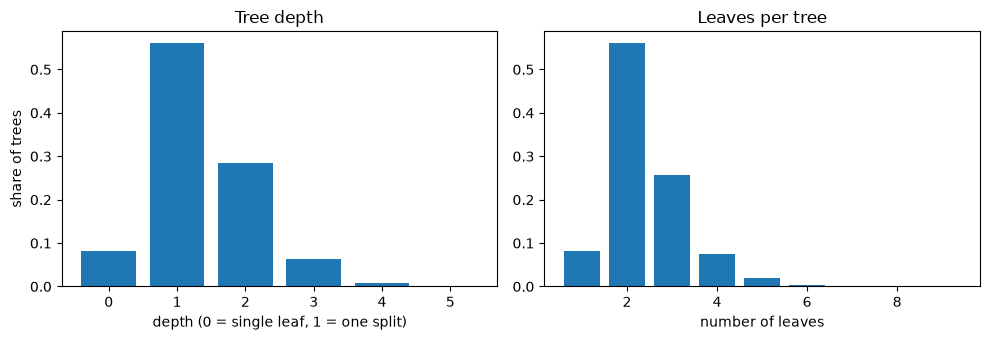

In [14]:
forest = reg.forest_summary()
print("share of trees by depth:")
print(forest.depth_distribution().round(3).to_string())
plot_tree_sizes(forest);

,mean_splits_per_draw,share_of_splits
feature,,
num_184,10.6265,0.037817
num_133,10.5265,0.037461
num_80,5.8740,0.020904
num_130,4.0165,0.014294
num_52,3.9065,0.013902
bin_0,3.7520,0.013352
num_131,3.7505,0.013347
num_69,3.2885,0.011703
num_135,2.9935,0.010653


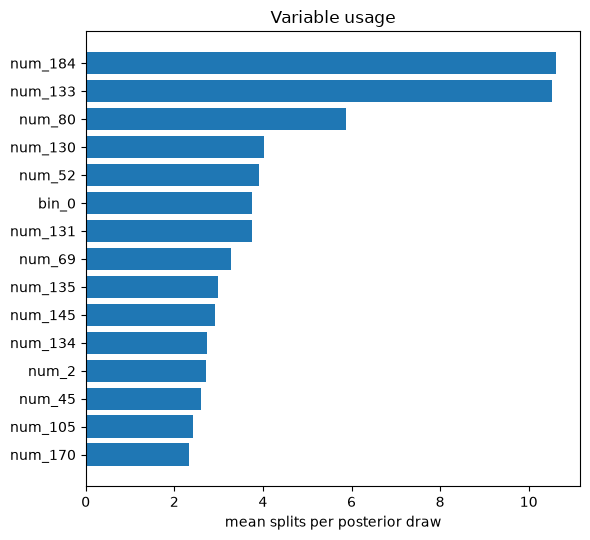

In [15]:
plot_variable_usage(forest, top=15)
forest.variable_usage().head(10)

In [16]:
reg.split_points().head(10)  # most used cut values (a row goes right if x > cutpoint)

,feature,cutpoint,count
0,bin_0,0.500000,7504
1,cat_2,0.500000,4390
2,num_166_missing,0.500000,3627
3,num_167_missing,0.500000,3582
4,num_165_missing,0.500000,3240
5,num_168_missing,0.500000,3219
6,num_175,-0.969502,2747
7,num_169_missing,0.500000,2628
8,bin_1,0.500000,2563
9,num_184,-1.283132,2533


In [17]:
# one sampled tree with at least 3 splits
tree = int(np.argmax(forest.n_splits[0, -1] >= 3))
print(reg.format_tree(chain=0, draw=reg.n_save - 1, tree=tree))

if num_123 <= 0.7784:
    if num_171 <= -0.08891:
        leaf +0.01511
    else:  # num_171 > -0.08891 or missing
        leaf -0.02309
else:  # num_123 > 0.7784 or missing
    if num_105 <= 1.027:
        leaf -0.03749
    else:  # num_105 > 1.027 or missing
        leaf -0.05976


## Part 2. Classification: homesite-insurance

`BartClassifier` is **probit** BART: P(y = 1 | x) = Phi(f(x)). There is no noise sd sigma; the
intervals are for the probability p(x).

In [18]:
X_train, y_train, X_test, y_test = load_tabred("homesite-insurance")
print("columns with NaN:", int(X_train.isna().any().sum()), "of", X_train.shape[1])
print("columns missing in > 50% of rows:", int((X_train.isna().mean() > 0.5).sum()))
print("train", X_train.shape, "test", X_test.shape, "share of y = 1:", y_train.mean().round(3))

columns with NaN: 70 of 299
columns missing in > 50% of rows: 1
train (20000, 299) test (5000, 299) share of y = 1: 0.185


In [19]:
start = time.time()
clf = BartClassifier(**BART_SETTINGS).fit(X_train, y_train)  # imputes NaN itself
bart_proba = clf.predict_proba(X_test)[:, 1]
print(f"BART fit + predict: {time.time() - start:.0f}s")
print("missing indicators added by BART:", len(clf.model_feature_names_) - X_train.shape[1])

xgb_clf = XGBDefaultClassifier().fit(X_train, y_train)
xgb_proba = xgb_clf.predict_proba(X_test)[:, 1]
bart_auc, xgb_auc = roc_auc_score(y_test, bart_proba), roc_auc_score(y_test, xgb_proba)
print(f"test AUC  BART {bart_auc:.4f}   XGBoost {xgb_auc:.4f}")

BART fit + predict: 20s
missing indicators added by BART: 1


test AUC  BART 0.9528   XGBoost 0.9516


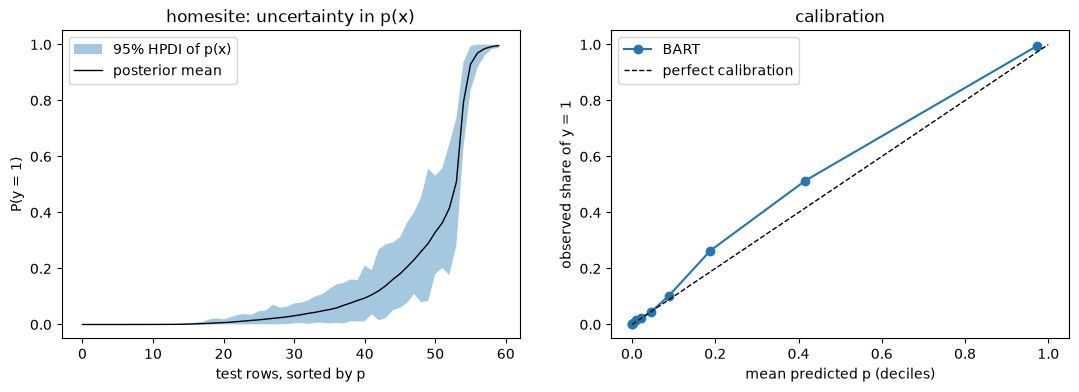

In [20]:
p_ci = clf.predict_interval(X_test, prob=0.95)  # 95% HPDI of p(x)
show = np.argsort(bart_proba)[:: len(bart_proba) // 60][:60]
x = np.arange(len(show))
fig, (left, right) = plt.subplots(1, 2, figsize=(13, 4))
left.fill_between(x, p_ci.lower[show], p_ci.upper[show], alpha=0.4, label="95% HPDI of p(x)")
left.plot(x, bart_proba[show], "k-", lw=1, label="posterior mean")
left.set(xlabel="test rows, sorted by p", ylabel="P(y = 1)", title="homesite: uncertainty in p(x)")
left.legend(loc="upper left")

bins = pd.qcut(bart_proba, 10, duplicates="drop")
calib = pd.DataFrame({"p": bart_proba, "y": y_test}).groupby(bins, observed=True).mean()
right.plot(calib["p"], calib["y"], "o-", label="BART")
right.plot([0, 1], [0, 1], "k--", lw=1, label="perfect calibration")
right.set(
    xlabel="mean predicted p (deciles)", ylabel="observed share of y = 1", title="calibration"
)
right.legend();

In [21]:
clf.posterior_summary()

,mean,sd,hpdi_0.95_low,hpdi_0.95_high,rhat,ess_bulk,ess_tail,ok
name,,,,,,,,
mean_tree_leaves,2.544863,0.058148,2.435,2.660,1.062101,55.148963,316.208424,False
mean_tree_depth,1.478855,0.050348,1.370,1.565,1.067498,56.513722,346.756481,False


In [22]:
clf.diagnostics()[["mean", "rhat", "ess_bulk", "ess_tail", "ok"]]

/var/folders/z6/6gqdsxwx6blf3zqz985_x_b40000gn/T/ipykernel_30875/861839358.py:1: UserWarning: Possible lack of convergence for: ['mean_tree_leaves', 'mean_tree_depth', 'f(x_probe[0])', 'f(x_probe[1])', 'f(x_probe[2])', 'f(x_probe[3])', 'f(x_probe[4])', 'f(x_probe[5])', 'f(x_probe[6])', 'f(x_probe[7])', 'f(x_probe[8])', 'f(x_probe[9])', 'f(x_probe[10])', 'f(x_probe[11])', 'f(x_probe[12])', 'f(x_probe[13])', 'f(x_probe[14])', 'f(x_probe[15])', 'f(x_probe[16])', 'f(x_probe[17])', 'f(x_probe[18])', 'f(x_probe[19])']
  clf.diagnostics()[["mean", "rhat", "ess_bulk", "ess_tail", "ok"]]


,mean,rhat,ess_bulk,ess_tail,ok
name,,,,,
mean_tree_leaves,2.544863e+00,1.062101,55.148963,316.208424,False
mean_tree_depth,1.478855e+00,1.067498,56.513722,346.756481,False
accept_rate,3.013125e-01,0.999939,1294.052523,1700.097453,True
f(x_probe[0]),9.968227e-01,1.147881,19.834651,192.293795,False
f(x_probe[1]),1.665499e-10,1.219899,13.338764,53.903579,False
f(x_probe[2]),1.953736e-03,1.508252,7.705319,66.759177,False
f(x_probe[3]),3.365916e-01,1.557816,7.156660,40.744349,False
f(x_probe[4]),7.858754e-02,1.379851,9.188958,32.786910,False
f(x_probe[5]),7.180794e-04,1.307637,10.332746,31.953450,False


,mean_splits_per_draw,share_of_splits
feature,,
num_36,9.9540,0.032216
bin_11,7.6195,0.024661
bin_3,6.0685,0.019641
bin_4,5.2590,0.017021
num_41,5.2315,0.016932
num_40,5.1175,0.016563
num_133_missing,5.0435,0.016323
num_23,4.7460,0.015361
num_19,4.2395,0.013721


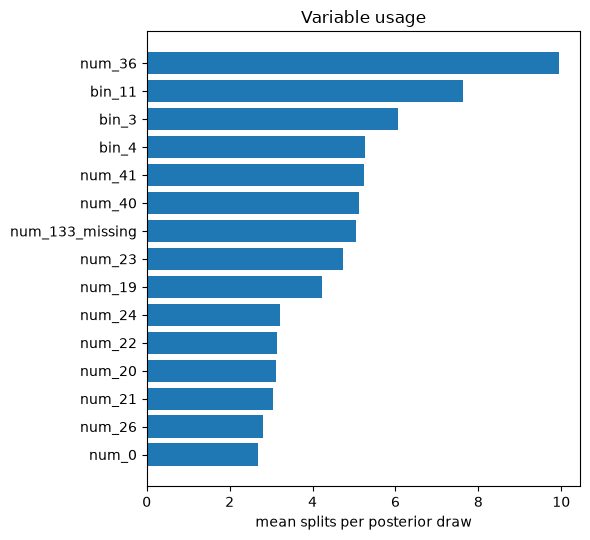

In [23]:
forest = clf.forest_summary()
plot_variable_usage(forest, top=15)
forest.variable_usage().head(10)

## Notes

- **Scaling up.** Set `N_TRAIN = None` and more trees / draws on a GPU (e.g. Colab). Predicting is
  test rows x draws x trees: for many test rows, use fewer saved draws (`n_save`) or batch rows.
- **Convergence first.** Check `diagnostics()` before trusting intervals; increase `n_burn` /
  `n_save` or `num_chains` when rows are flagged.
- **Saving.** `reg.save("folder")` / `BartRegressor.load("folder")` use bartz's version-tied format:
  fine for caching, not for archiving.